In [81]:
import pandapower as pp 
import numpy as np 

## Network A 

In [82]:
net_A = pp.create_empty_network()

# create all 42 buses 
buses = {}
# hv buses 
for i in range(1, 3): 
    buses[f'b{i}'] =  pp.create_bus(net_A, vn_kv=110., name=f'HV{i} - Bus {i}')

# mv buses 
for i in range(3, 25):
    buses[f'b{i}'] = pp.create_bus(net_A, vn_kv=20., name=f'MV{i-2} - Bus {i}')

# lv buses 
for i in range(25, 43): 
    buses[f'b{i}'] = pp.create_bus(net_A, vn_kv=0.4, name=f'LV{i-24} - Bus {i}')

# create all 20 loads 
buses_with_loads = np.array([34,35,39,15,5,21,9,12,16,13,11,8,7,10,22,6,23,17,19,20]) + 1 
p_mw_loads = [0.033,0.009,0.051,0.093,0.090,0.153,0.225,0.096,0.801,0.054,0.003,0.303,
              0.156,0.033,0.102,0.156,0.621,0.108,1.302,0.003]
for i, j in zip(buses_with_loads, p_mw_loads): 
    pp.create_load(net_A, bus=buses[f'b{i}'], p_mw=j, q_mvar=0.0, name=f'Load at Bus {i}')

# create 2 external grids 
pp.create_ext_grid(net_A, bus=buses['b1'], vm_pu=1.02)
pp.create_ext_grid(net_A, bus=buses['b2'], vm_pu=1.02) 


# Create 22 Lines and 20 Transformers using standard type libraries


"""
Selecting three standard line types: 
1. NA2XS2Y 1x150 RM/25 12/20 kV
2. NA2XS2Y 1x120 RM/25 12/20 kV
3. NA2XS2Y 1x70 RM/25 12/20 kV
"""
from_buses = np.array([2,2,14,3,4,20,13,15,3,22,6,3,3,2,12,10,2,7,9,5,11,2]) + 1
to_buses = np.array([23,16,20,19,11,5,8,8,6,17,14,19,10,7,21,12,4,13,15,22,18,16]) + 1
length_line_buses = [0.09296, 1.16192, 0.29181, 0.61771, 0.58316, 0.36308, 0.69365,
       0.26261, 0.5495 , 0.10406, 0.0292 , 0.61681, 0.20117, 0.28499,
       0.09897, 0.09703, 0.02746, 0.17044, 0.34013, 0.57467, 1.87198,
       1.16144]
std_types = {}
std_types[0] = 'NA2XS2Y 1x150 RM/25 12/20 kV'
std_types[1] = 'NA2XS2Y 1x120 RM/25 12/20 kV'
std_types[2] = 'NA2XS2Y 1x70 RM/25 12/20 kV'

for from_bus, to_bus, length in zip(from_buses, to_buses, length_line_buses):
    
    rand_std = np.random.randint(0,3)

    pp.create_line(net_A, 
                   from_bus=buses[f'b{from_bus}'], 
                   to_bus=buses[f'b{to_bus}'],
                   length_km=length,
                   std_type=std_types[rand_std])

"""
Selecting three standard transformer types: 
1. 0.25 MVA 20/0.4 kV
2. 0.4 MVA 20/0.4 kV
3. 0.63 MVA 20/0.4 kV
"""
# hv/mv transformers 
pp.create_transformer(net_A, 
                      hv_bus=buses['b1'], 
                      lv_bus=buses['b4'], 
                      std_type='25 MVA 110/20 kV', 
                      name = "HV Trafo 1")
pp.create_transformer(net_A, 
                      hv_bus=buses['b2'], 
                      lv_bus=buses['b3'], 
                      std_type='25 MVA 110/20 kV', 
                      name = "HV Trafo 2")

# mv/lv transformers 
mv_buses = np.array([15,21,12,16,11,7,10,13,22,8,14,4,17,9,6,18,5,20]) + 1 
lv_buses = np.array([24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41]) + 1 

std_t_types = {}
std_t_types[0] = '0.25 MVA 20/0.4 kV'
std_t_types[1] = '0.4 MVA 20/0.4 kV'
std_t_types[2] = '0.63 MVA 20/0.4 kV'

for mv_bus, lv_bus in zip(mv_buses, lv_buses):
    rand_std = np.random.randint(0,3)
    pp.create_transformer(net_A, 
                          hv_bus=buses[f'b{mv_bus}'], 
                          lv_bus=buses[f'b{lv_bus}'],
                          std_type=std_t_types[rand_std], 
                          name='MV/LV Trafo')

In [83]:
net_A

This pandapower network includes the following parameter tables:
   - bus (42 elements)
   - load (20 elements)
   - ext_grid (2 elements)
   - line (22 elements)
   - trafo (20 elements)

In [84]:
pp.runpp(net_A)

# Network B 

In [87]:
net_B = pp.create_empty_network()

# create all 42 buses 
buses = {}
# hv buses 
for i in range(1, 3): 
    buses[f'b{i}'] =  pp.create_bus(net_B, vn_kv=110., name=f'HV{i} - Bus {i}')

# mv buses 
for i in range(3, 25):
    buses[f'b{i}'] = pp.create_bus(net_B, vn_kv=20., name=f'MV{i-2} - Bus {i}')

# lv buses 
for i in range(25, 43): 
    buses[f'b{i}'] = pp.create_bus(net_B, vn_kv=0.4, name=f'LV{i-24} - Bus {i}')

# create all 20 loads 
buses_with_loads = np.array([26,28,29,32,33,34,35,38,15,10,11,13,16,7,21,20,22,5,14]) + 1 
p_mw_loads = [0.063, 0.075, 0.096, 0.159, 0.075, 0.189, 0.186, 0.156, 0.132,
       0.054, 0.03 , 0.186, 0.219, 0.231, 0.261, 0.258, 0.102, 0.162, 0.756]
for i, j in zip(buses_with_loads, p_mw_loads): 
    pp.create_load(net_B, bus=buses[f'b{i}'], p_mw=j, q_mvar=0.0, name=f'Load at Bus {i}')

# create 2 external grids 
pp.create_ext_grid(net_B, bus=buses['b1'], vm_pu=1.02)
pp.create_ext_grid(net_B, bus=buses['b2'], vm_pu=1.02) 


# Create 20 Lines and 20 Transformers using standard type libraries

"""
Selecting three standard line types: 
1. NA2XS2Y 1x150 RM/25 12/20 kV
2. NA2XS2Y 1x120 RM/25 12/20 kV
3. NA2XS2Y 1x70 RM/25 12/20 kV
"""
from_buses = np.array([20,  2,  4,  5, 10, 18,  6, 22,  9, 15,  3,  2, 21, 11, 12,  3, 23,
        8, 14, 16]) + 1
to_buses = np.array([ 9, 12,  8,  7, 20,  5,  4, 23, 11, 16, 18, 10, 22, 17,  6, 14, 13,
       19, 15, 13]) + 1
length_line_buses = [0.32778, 1.76219, 0.56939, 1.30243, 0.2314 , 0.35837, 0.20894,
       0.10514, 0.58274, 0.91073, 0.62708, 0.64831, 0.37062, 0.06237,
       0.36216, 1.58439, 0.02965, 0.00553, 0.24427, 0.7401 ]
std_types = {}
std_types[0] = 'NA2XS2Y 1x150 RM/25 12/20 kV'
std_types[1] = 'NA2XS2Y 1x120 RM/25 12/20 kV'
std_types[2] = 'NA2XS2Y 1x70 RM/25 12/20 kV'

for from_bus, to_bus, length in zip(from_buses, to_buses, length_line_buses):
    
    rand_std = np.random.randint(0,3)

    pp.create_line(net_B, 
                   from_bus=buses[f'b{from_bus}'], 
                   to_bus=buses[f'b{to_bus}'],
                   length_km=length,
                   std_type=std_types[rand_std])

"""
Selecting three standard transformer types: 
1. 0.25 MVA 20/0.4 kV
2. 0.4 MVA 20/0.4 kV
3. 0.63 MVA 20/0.4 kV
"""
# hv/mv transformers 
pp.create_transformer(net_B, 
                      hv_bus=buses['b1'], 
                      lv_bus=buses['b4'], 
                      std_type='25 MVA 110/20 kV', 
                      name = "HV Trafo 1")
pp.create_transformer(net_B, 
                      hv_bus=buses['b2'], 
                      lv_bus=buses['b3'], 
                      std_type='25 MVA 110/20 kV', 
                      name = "HV Trafo 2")

# mv/lv transformers 
mv_buses = np.array([15, 10, 12, 11, 17,  9,  7, 21, 18,  8,  4,  6, 13,  5, 19,
       22, 16, 23]) + 1 
lv_buses = np.array([24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41]) + 1 

std_t_types = {}
std_t_types[0] = '0.25 MVA 20/0.4 kV'
std_t_types[1] = '0.4 MVA 20/0.4 kV'
std_t_types[2] = '0.63 MVA 20/0.4 kV'

for mv_bus, lv_bus in zip(mv_buses, lv_buses):
    rand_std = np.random.randint(0,3)
    pp.create_transformer(net_B, 
                          hv_bus=buses[f'b{mv_bus}'], 
                          lv_bus=buses[f'b{lv_bus}'],
                          std_type=std_t_types[rand_std], 
                          name='MV/LV Trafo')

In [88]:
net_B

This pandapower network includes the following parameter tables:
   - bus (42 elements)
   - load (19 elements)
   - ext_grid (2 elements)
   - line (20 elements)
   - trafo (20 elements)

In [91]:
pp.runpp(net_B)

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


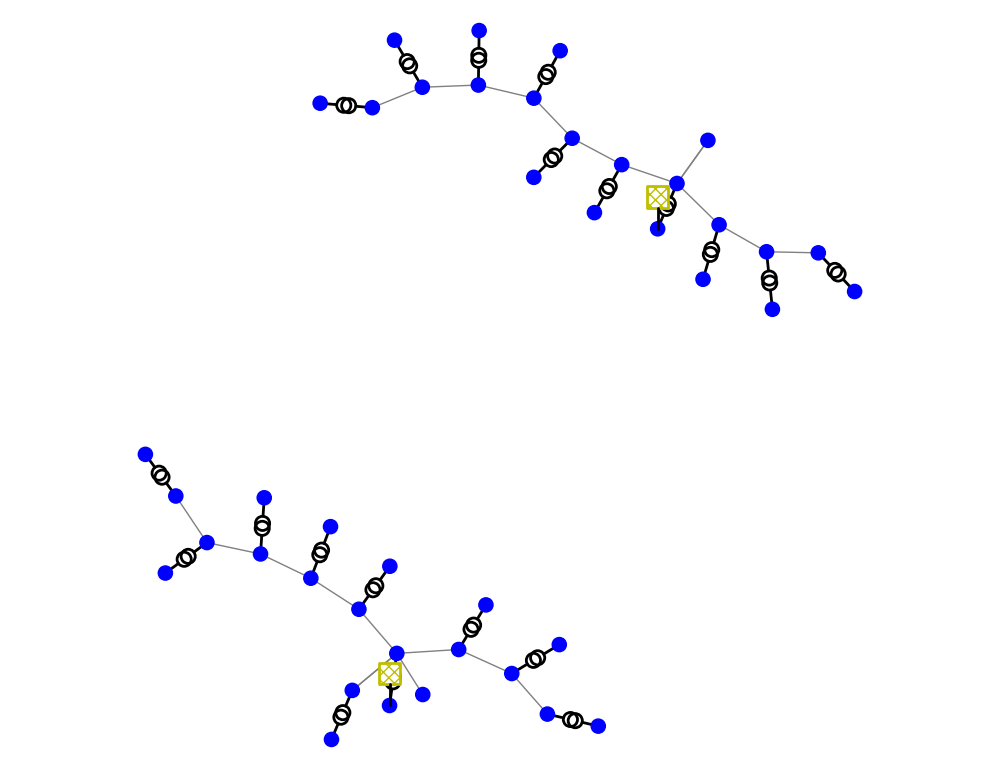

<Axes: >

In [89]:
pp.plotting.simple_plot(net_A)

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


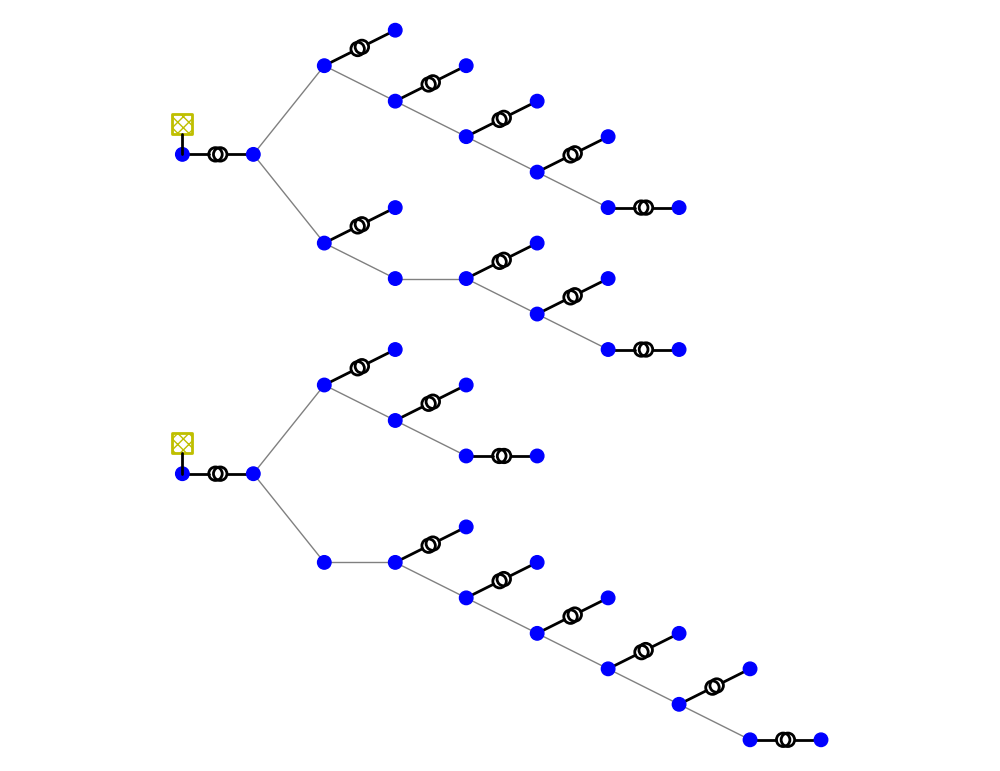

<Axes: >

In [90]:
pp.plotting.simple_plot(net_B)